# Bevezetés a neurális hálózatokba

Ebben a jegyzetben ugyanazt az alapötletet építjük fel lépésenként: egy modell paramétereit úgy választjuk meg, hogy a predikció hibája kicsi legyen.

## Tanulási célok

A notebook végére képes leszel:

- egyszerű lineáris regresszió optimális paramétereit analitikusan és gradiens módszerrel meghatározni;
- több bemeneti változó esetén vektorizált modellt használni;
- megérteni a logisztikus regresszió és a bináris keresztentrópia kapcsolatát;
- felismerni, mikor nem elég egy lineáris döntési határ;
- egyrétegű neurális hálót tanítani és L2-regularizációval mérsékelni a túlillesztést;
- többosztályos MNIST-osztályozót készíteni softmax szemlélettel.

A kódok Google Colabban is futtathatók. GPU használata nem kötelező, de az MNIST-példát gyorsítja.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# A véletlen inicializálás legyen minden futtatáskor megismételhető.
np.random.seed(42)
torch.manual_seed(42)

# Colab T4 esetén CUDA-t, más környezetben CPU-t használunk.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Használt eszköz: {device}")

Használt eszköz: cuda


---

# 1. Regresszió

A regresszió célja folytonos érték előrejelzése. Először egyetlen bemeneti változót használunk, és az

$$\hat{y}=wx+b$$

alakú egyenest illesztjük. A $w$ a meredekség, $b$ a tengelymetszet, $\hat{y}$ pedig a becslés.

A paramétereket az átlagos négyzetes hiba (MSE) minimalizálásával választjuk:

$$L(w,b)=\frac{1}{n}\sum_{i=1}^{n}(wx_i+b-y_i)^2.$$

## 1.1 Egyszerű lineáris regresszió: adatok

Mindig az adatok megtekintésével kezdünk. A grafikon segít ellenőrizni a skálát, a zajt, a kiugró értékeket és azt, hogy ésszerű-e egy egyenes modellt választani.

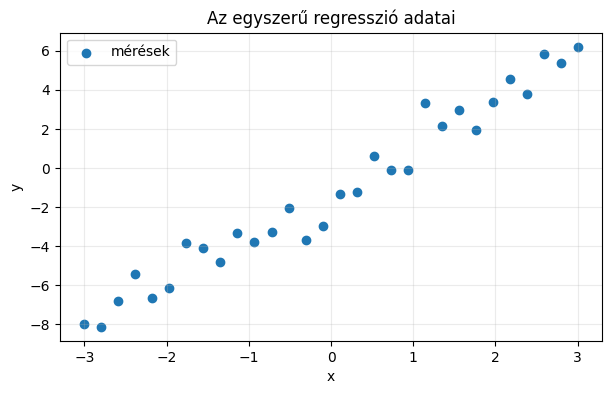

In [2]:
# Mesterséges mérési adatok: a valódi kapcsolat közelítőleg y = 2.5x - 1.
x_simple = np.linspace(-3, 3, 30)
y_simple = 2.5 * x_simple - 1.0 + np.random.normal(0, 1.0, x_simple.shape)

plt.figure(figsize=(7, 4))
plt.scatter(x_simple, y_simple, color="tab:blue", label="mérések")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Az egyszerű regresszió adatai")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Analitikus optimum NumPy-val

Mivel az MSE $w$ és $b$ szerint konvex másodfokú függvény, a minimum ott található, ahol mindkét parciális derivált nulla:

$$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_i x_i(wx_i+b-y_i)=0,$$

$$\frac{\partial L}{\partial b}=\frac{2}{n}\sum_i(wx_i+b-y_i)=0.$$

Ez a két egyenlet a **normálegyenlethez** vezet. Mátrixos alakban $X\theta\approx y$, ahol az első oszlop az $x$ értékeket, a második csupa egyest tartalmaz, és $\theta=[w,b]^T$. A `np.linalg.lstsq` stabilan megoldja ezt a legkisebb négyzetes problémát.

Analitikus megoldás: w = 2.330, b = -1.188
MSE = 0.691


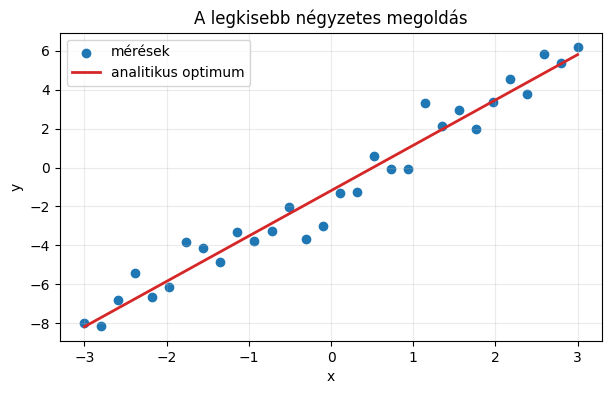

In [3]:
# A második oszlop miatt a b tengelymetszet is a paramétervektor része.
X_design = np.column_stack([x_simple, np.ones_like(x_simple)])
w_numpy, b_numpy = np.linalg.lstsq(X_design, y_simple, rcond=None)[0]
y_numpy = w_numpy * x_simple + b_numpy
mse_numpy = np.mean((y_numpy - y_simple) ** 2)

print(f"Analitikus megoldás: w = {w_numpy:.3f}, b = {b_numpy:.3f}")
print(f"MSE = {mse_numpy:.3f}")

plt.figure(figsize=(7, 4))
plt.scatter(x_simple, y_simple, color="tab:blue", label="mérések")
plt.plot(x_simple, y_numpy, color="tab:red", linewidth=2, label="analitikus optimum")
plt.xlabel("x")
plt.ylabel("y")
plt.title("A legkisebb négyzetes megoldás")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Ugyanez gradiens módszerrel PyTorchban

Nagyobb modelleknél az analitikus megoldás gyakran túl drága vagy nem is létezik zárt alakban. Ekkor iteratívan haladunk a veszteség negatív gradiense felé:

$$\theta_{t+1}=\theta_t-\eta\nabla_\theta L,$$

ahol $\eta$ a tanulási ráta. A PyTorch automatikus deriválása kiszámítja a gradienseket a `loss.backward()` híváskor.

Dokumentáció:

- [`torch.Tensor.backward`](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html)
- [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- [`torch.nn.MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

Gradiens módszer: w = 2.330, b = -1.188


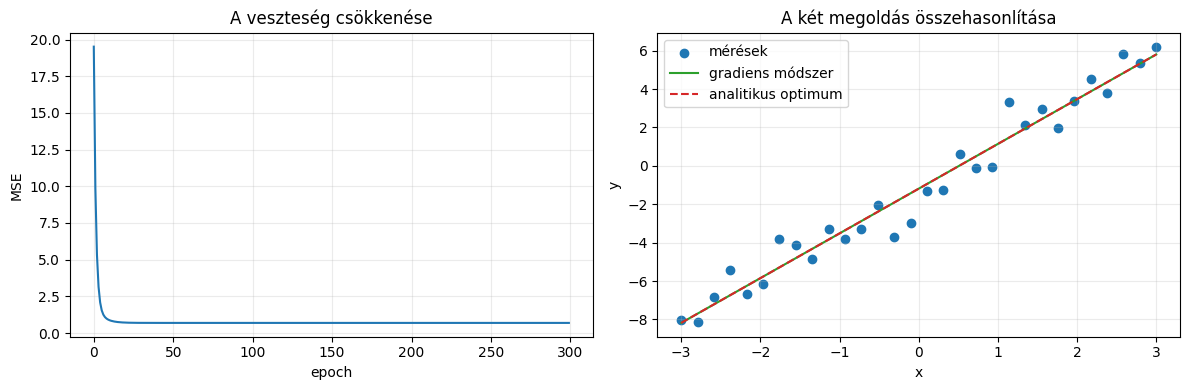

In [4]:
x_t = torch.tensor(x_simple, dtype=torch.float32).reshape(-1, 1)
y_t = torch.tensor(y_simple, dtype=torch.float32).reshape(-1, 1)

# A két skalár most tanulható paraméter; kezdetben szándékosan nullák.
w = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
criterion_mse = nn.MSELoss()
optimizer = torch.optim.SGD([w, b], lr=0.05)
loss_history = []

for epoch in range(300):
    y_hat = w * x_t + b
    loss = criterion_mse(y_hat, y_t)

    # A korábbi gradienseket törölni kell, mert a PyTorch összeadná őket.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(f"Gradiens módszer: w = {w.item():.3f}, b = {b.item():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set(xlabel="epoch", ylabel="MSE", title="A veszteség csökkenése")
axes[0].grid(alpha=0.25)
axes[1].scatter(x_simple, y_simple, color="tab:blue", label="mérések")
axes[1].plot(x_simple, (w.detach() * x_t + b.detach()).numpy(), color="tab:green", label="gradiens módszer")
axes[1].plot(x_simple, y_numpy, "--", color="tab:red", label="analitikus optimum")
axes[1].set(xlabel="x", ylabel="y", title="A két megoldás összehasonlítása")
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

## 1.2 Lineáris regresszió több tanulható paraméterrel

Most minden mintához három jellemző tartozik. A modell

$$\hat{y}=w_1x_1+w_2x_2+w_3x_3+b=\mathbf{x}^T\mathbf{w}+b.$$

A **vektorizáció** azt jelenti, hogy nem írunk külön képletet minden mintára és jellemzőre. Az egész adathalmaz predikciója egyetlen mátrixszorzás:

$$\hat{\mathbf{y}}=X\mathbf{w}+b.$$

Először itt is megvizsgáljuk az adatokat. Három dimenziót nehéz egyszerre ábrázolni, ezért mindegyik jellemző és a célváltozó kapcsolatát külön grafikonon nézzük meg.

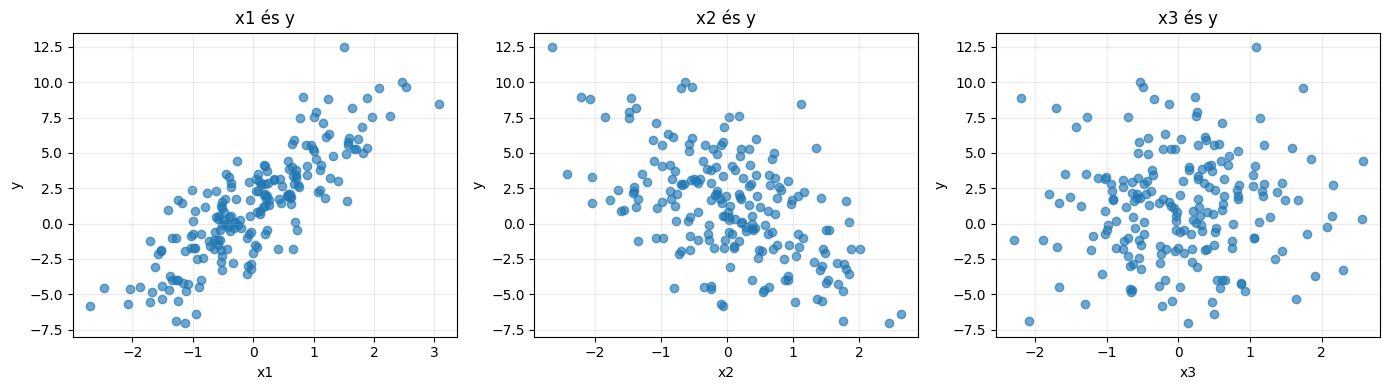

In [15]:
n_samples = 200
X_multi = np.random.normal(size=(n_samples, 3)).astype(np.float32)
true_weights = np.array([3.0, -2.0, 0.5], dtype=np.float32)
y_multi = X_multi @ true_weights + 1.2 + np.random.normal(0, 0.5, n_samples)
y_multi = y_multi.astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for feature_index, axis in enumerate(axes):
    axis.scatter(X_multi[:, feature_index], y_multi, alpha=0.65)
    axis.set(xlabel=f"x{feature_index + 1}", ylabel="y", title=f"x{feature_index + 1} és y")
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

A [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) réteg pontosan az $XW^T+b$ vektorizált műveletet valósítja meg. A három bemeneti jellemzőhöz három súly, az egy kimenethez pedig egy bias tartozik. A tanulási ciklus ugyanaz marad, mint az egyszerű esetben.

Valódi súlyok:  [ 3.  -2.   0.5]
Tanult súlyok:  [ 3.    -1.976  0.476]
Valódi bias: 1.200, tanult bias: 1.241


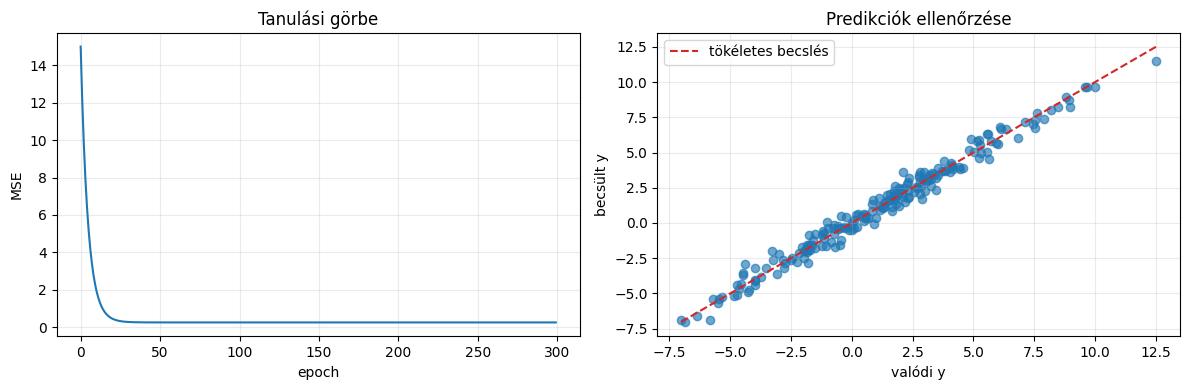

In [16]:
X_multi_t = torch.from_numpy(X_multi)
y_multi_t = torch.from_numpy(y_multi).reshape(-1, 1)

multi_model = nn.Linear(in_features=3, out_features=1)
multi_optimizer = torch.optim.SGD(multi_model.parameters(), lr=0.05)
multi_losses = []

for epoch in range(300):
    predictions = multi_model(X_multi_t)
    loss = criterion_mse(predictions, y_multi_t)
    multi_optimizer.zero_grad()
    loss.backward()
    multi_optimizer.step()
    multi_losses.append(loss.item())

learned_weights = multi_model.weight.detach().squeeze().numpy()
learned_bias = multi_model.bias.detach().item()
print("Valódi súlyok: ", true_weights)
print("Tanult súlyok: ", np.round(learned_weights, 3))
print(f"Valódi bias: 1.200, tanult bias: {learned_bias:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(multi_losses)
axes[0].set(xlabel="epoch", ylabel="MSE", title="Tanulási görbe")
axes[0].grid(alpha=0.25)
axes[1].scatter(y_multi, multi_model(X_multi_t).detach().squeeze().numpy(), alpha=0.65)
limits = [y_multi.min(), y_multi.max()]
axes[1].plot(limits, limits, "--", color="tab:red", label="tökéletes becslés")
axes[1].set(xlabel="valódi y", ylabel="becsült y", title="Predikciók ellenőrzése")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

---

# 2. Osztályozás

Osztályozáskor nem folytonos értéket, hanem kategóriát becslünk. Bináris esetben legyen $y\in\{0,1\}$. A logisztikus regresszió először egy lineáris pontszámot, más néven **logitot** számít:

$$z=\mathbf{x}^T\mathbf{w}+b,$$

majd ezt a szigmoid függvény alakítja valószínűséggé:

$$P(y=1\mid\mathbf{x})=\sigma(z)=\frac{1}{1+e^{-z}}.$$

A modell az 1-es osztályt választja, ha a valószínűség legalább 0,5. Ez a $z=0$ egyenlet miatt mindig lineáris döntési határt jelent.

## 2.1 Logisztikus regresszió lineárisan szeparálható adatokon

Először rajzoljuk ki a két osztályt.

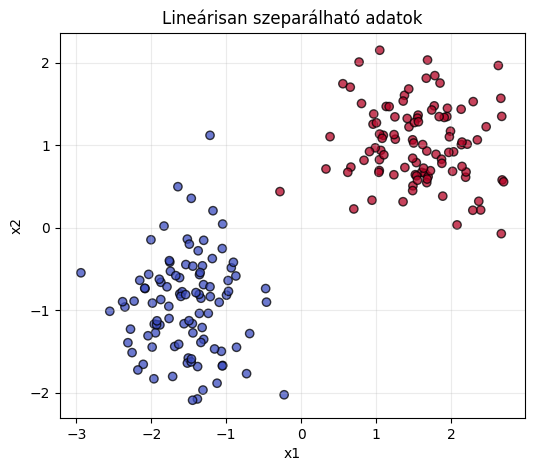

In [5]:
n_per_class = 100
class_0 = np.random.normal(loc=(-1.5, -1.0), scale=0.55, size=(n_per_class, 2))
class_1 = np.random.normal(loc=(1.5, 1.0), scale=0.55, size=(n_per_class, 2))
X_separable = np.vstack([class_0, class_1]).astype(np.float32)
y_separable = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.float32)

plt.figure(figsize=(6, 5))
plt.scatter(X_separable[:, 0], X_separable[:, 1], c=y_separable, cmap="coolwarm", edgecolor="black", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Lineárisan szeparálható adatok")
plt.grid(alpha=0.25)
plt.show()

A numerikusan stabil [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) egyesíti a szigmoidot és a bináris keresztentrópiát:

$$L=-\frac{1}{n}\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].$$

Ezért tanításkor a modell nyers logitját adjuk a veszteségfüggvénynek. A szigmoidot csak akkor hívjuk meg külön, amikor értelmezhető valószínűséget szeretnénk.

Tanítási pontosság: 100.0%


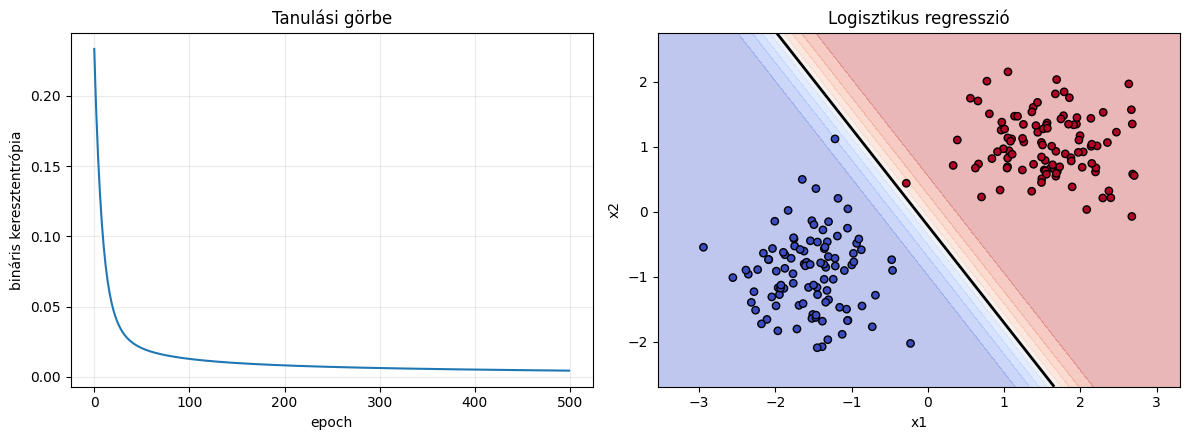

In [6]:
def train_binary_model(model, X, y, epochs=500, learning_rate=0.05, weight_decay=0.0):
    """Bináris osztályozó tanítása és a veszteségek visszaadása."""
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    losses = []
    for _ in range(epochs):
        logits = model(X).squeeze(1)
        loss = loss_function(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


def binary_accuracy(model, X, y):
    """A 0,5 küszöbbel kapott bináris pontosság."""
    with torch.no_grad():
        predictions = (torch.sigmoid(model(X).squeeze(1)) >= 0.5).float()
    return (predictions == y).float().mean().item()


def plot_decision_surface(model, X, y, title, axis=None):
    """A modell döntési tartományának és adatpontjainak ábrázolása."""
    if axis is None:
        _, axis = plt.subplots(figsize=(6, 5))
    x1 = np.linspace(X[:, 0].min() - 0.6, X[:, 0].max() + 0.6, 180)
    x2 = np.linspace(X[:, 1].min() - 0.6, X[:, 1].max() + 0.6, 180)
    grid_x1, grid_x2 = np.meshgrid(x1, x2)
    grid = torch.tensor(np.c_[grid_x1.ravel(), grid_x2.ravel()], dtype=torch.float32)
    model_device = next(model.parameters()).device
    with torch.no_grad():
        probabilities = torch.sigmoid(model(grid.to(model_device)).squeeze(1)).cpu().numpy()
    probabilities = probabilities.reshape(grid_x1.shape)
    axis.contourf(grid_x1, grid_x2, probabilities, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    axis.contour(grid_x1, grid_x2, probabilities, levels=[0.5], colors="black", linewidths=2)
    axis.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=28)
    axis.set(xlabel="x1", ylabel="x2", title=title)

X_sep_t = torch.from_numpy(X_separable)
y_sep_t = torch.from_numpy(y_separable)
logistic_model = nn.Linear(2, 1)
logistic_losses = train_binary_model(logistic_model, X_sep_t, y_sep_t)

print(f"Tanítási pontosság: {100 * binary_accuracy(logistic_model, X_sep_t, y_sep_t):.1f}%")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(logistic_losses)
axes[0].set(xlabel="epoch", ylabel="bináris keresztentrópia", title="Tanulási görbe")
axes[0].grid(alpha=0.25)
plot_decision_surface(logistic_model, X_separable, y_separable, "Logisztikus regresszió", axes[1])
plt.tight_layout()
plt.show()

## 2.2 Amikor az adatok nem lineárisan szeparálhatók

A következő adathalmazban a belső kör a 0-s, a külső gyűrű az 1-es osztály. Nincs olyan egyenes, amely a két osztályt szétválasztaná. Az adatgeneráló függvényt később is használjuk, hogy ugyanazon a problémán hasonlíthassuk össze a modelleket.

A modell illesztése előtt ismét az adatokat rajzoljuk ki.

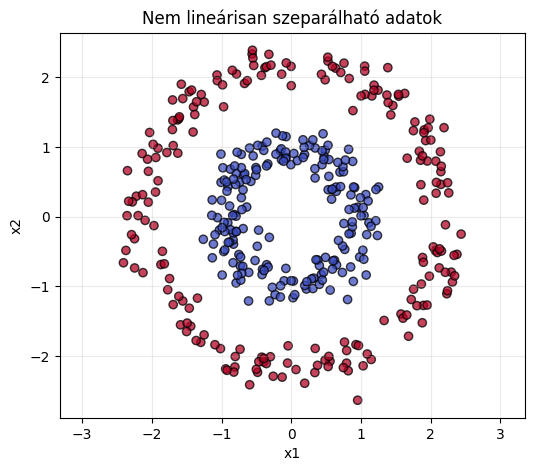

In [7]:
def make_rings(n_samples, noise=0.10, seed=0):
    """Két koncentrikus osztály előállítása."""
    generator = np.random.default_rng(seed)
    labels = generator.integers(0, 2, n_samples)
    angles = generator.uniform(0, 2 * np.pi, n_samples)
    radii = np.where(labels == 0, 1.0, 2.2) + generator.normal(0, noise, n_samples)
    features = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])
    return features.astype(np.float32), labels.astype(np.float32)

X_rings, y_rings = make_rings(400, noise=0.16, seed=1)

plt.figure(figsize=(6, 5))
plt.scatter(X_rings[:, 0], X_rings[:, 1], c=y_rings, cmap="coolwarm", edgecolor="black", alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Nem lineárisan szeparálható adatok")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.show()

Logisztikus regresszió pontossága: 47.7%


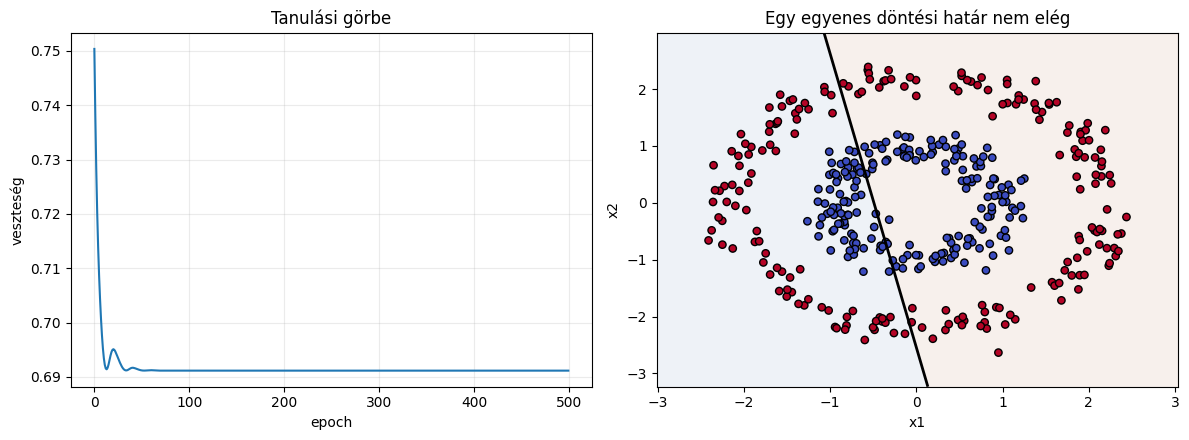

In [8]:
X_rings_t = torch.from_numpy(X_rings)
y_rings_t = torch.from_numpy(y_rings)

rings_logistic_model = nn.Linear(2, 1)
rings_logistic_losses = train_binary_model(
    rings_logistic_model, X_rings_t, y_rings_t, epochs=500
)
rings_logistic_accuracy = binary_accuracy(rings_logistic_model, X_rings_t, y_rings_t)

print(f"Logisztikus regresszió pontossága: {100 * rings_logistic_accuracy:.1f}%")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(rings_logistic_losses)
axes[0].set(xlabel="epoch", ylabel="veszteség", title="Tanulási görbe")
axes[0].grid(alpha=0.25)
plot_decision_surface(
    rings_logistic_model, X_rings, y_rings,
    "Egy egyenes döntési határ nem elég", axes[1]
)
plt.tight_layout()
plt.show()

---

# 3. Egyrétegű neurális hálózatok

Itt az „egyrétegű neurális hálózat” egy **rejtett réteget** jelent. A modell két lineáris transzformáció közé nemlineáris aktivációt tesz:

$$\mathbf{h}=\tanh(XW_1^T+\mathbf{b}_1),$$

$$\mathbf{z}=\mathbf{h}W_2^T+b_2.$$

A rejtett reprezentáció miatt a végső lineáris réteg már nem az eredeti síkon húz egyenest. Nemlineáris döntési határ jöhet létre.

Használt modulok:

- [`torch.nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html): rétegek sorba kapcsolása;
- [`torch.nn.Tanh`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html): nemlineáris aktiváció;
- [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html): affin transzformáció.

## 3.1 Egy rejtett réteg a gyűrű-adathalmazon

Az adatokat az előző ábrán már megvizsgáltuk. Most ugyanazokat a mintákat használjuk, így a logisztikus regresszióval való összehasonlítás korrekt.

Logisztikus regresszió: 47.7%
Egy rejtett réteg:      100.0%


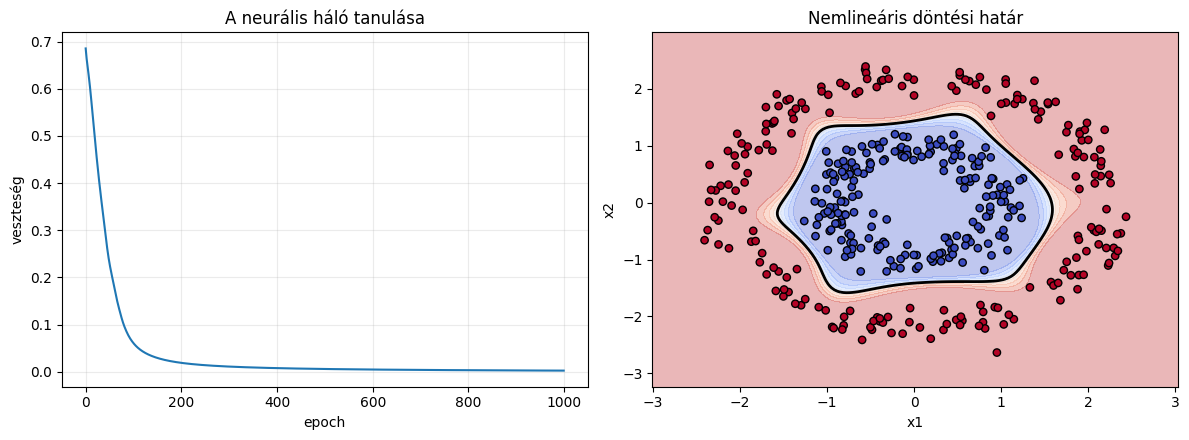

In [9]:
torch.manual_seed(42)
one_layer_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.Tanh(),
    nn.Linear(8, 1),
)
one_layer_losses = train_binary_model(
    one_layer_model, X_rings_t, y_rings_t, epochs=1000, learning_rate=0.03
)
one_layer_accuracy = binary_accuracy(one_layer_model, X_rings_t, y_rings_t)

print(f"Logisztikus regresszió: {100 * rings_logistic_accuracy:.1f}%")
print(f"Egy rejtett réteg:      {100 * one_layer_accuracy:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(one_layer_losses)
axes[0].set(xlabel="epoch", ylabel="veszteség", title="A neurális háló tanulása")
axes[0].grid(alpha=0.25)
plot_decision_surface(one_layer_model, X_rings, y_rings, "Nemlineáris döntési határ", axes[1])
plt.tight_layout()
plt.show()

## 3.2 Túlillesztés és L2-regularizáció

A nagy kapacitású modell kevés, zajos adaton akár a hibás címkéket is megtanulhatja. Ezt nevezzük **túlillesztésnek**: a tanítási pontosság magas, de új, tiszta adatokon romlik a teljesítmény.

Most ugyanabból a gyűrű-problémából készítünk:

- egy kicsi tanítóhalmazt, amelyben néhány címkét szándékosan megfordítunk;
- egy nagy, tiszta teszthalmazt.

Először ezeket az adatokat is megjelenítjük.

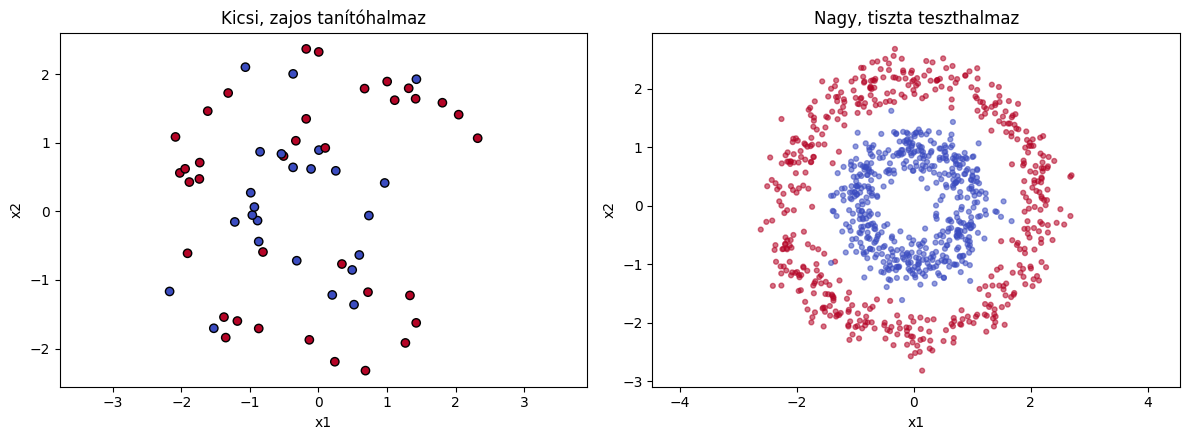

In [10]:
X_small_train, y_small_train = make_rings(60, noise=0.22, seed=10)
X_clean_test, y_clean_test = make_rings(1000, noise=0.22, seed=11)

# A tanítócímkék 20%-át megfordítjuk a mérési/címkézési zaj modellezésére.
noise_generator = np.random.default_rng(12)
flipped_indices = noise_generator.choice(len(y_small_train), size=12, replace=False)
y_noisy_train = y_small_train.copy()
y_noisy_train[flipped_indices] = 1 - y_noisy_train[flipped_indices]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_small_train[:, 0], X_small_train[:, 1], c=y_noisy_train, cmap="coolwarm", edgecolor="black")
axes[0].set(xlabel="x1", ylabel="x2", title="Kicsi, zajos tanítóhalmaz")
axes[0].axis("equal")
axes[1].scatter(X_clean_test[:, 0], X_clean_test[:, 1], c=y_clean_test, cmap="coolwarm", s=12, alpha=0.55)
axes[1].set(xlabel="x1", ylabel="x2", title="Nagy, tiszta teszthalmaz")
axes[1].axis("equal")
plt.tight_layout()
plt.show()

Az L2-regularizáció a nagy súlyokat bünteti:

$$L_{reg}=L_{adat}+\lambda\sum_j w_j^2.$$

Ez csökkenti a modell hajlamát arra, hogy nagyon éles, bonyolult döntési határral kövesse a zajt. A [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) `weight_decay` paramétere L2-jellegű súlycsökkenést ad. Az összehasonlítás kedvéért a két háló azonos inicializált paraméterekből indul; csak a regularizáció erőssége különbözik.

Regularizáció nélkül     | tanító: 100.0% | teszt:  70.8%
L2-regularizációval      | tanító:  81.7% | teszt:  87.1%


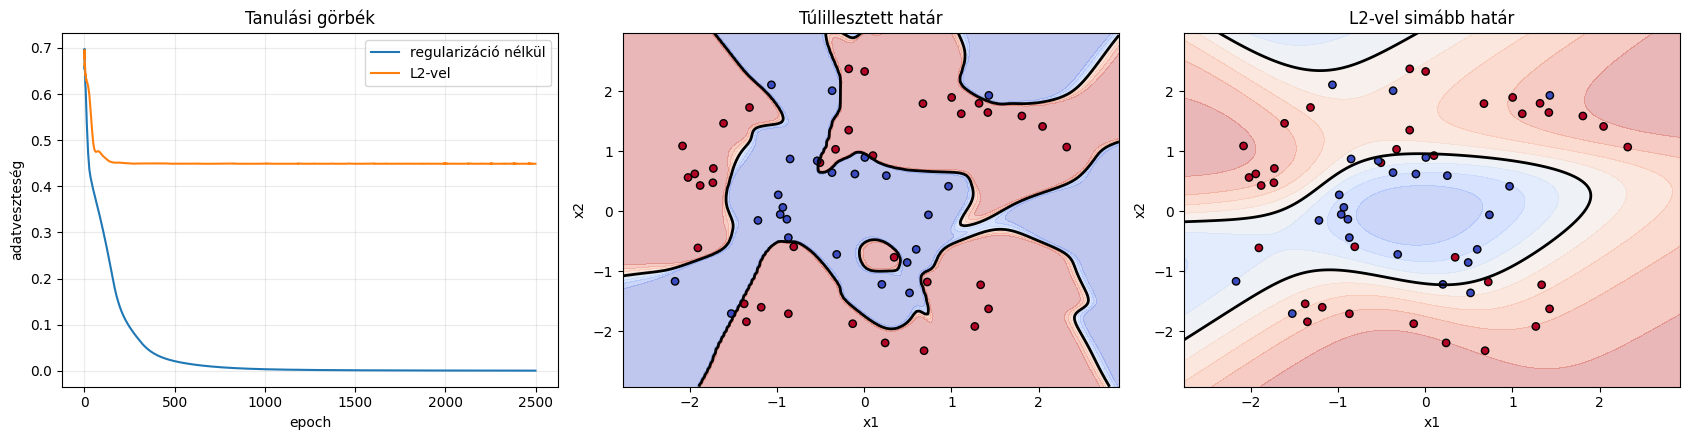

In [11]:
X_small_t = torch.from_numpy(X_small_train)
y_noisy_t = torch.from_numpy(y_noisy_train)
X_test_t = torch.from_numpy(X_clean_test)
y_test_t = torch.from_numpy(y_clean_test)


def make_large_one_layer_model():
    """A kevés adathoz képest szándékosan nagy kapacitású háló."""
    return nn.Sequential(
        nn.Linear(2, 128),
        nn.Tanh(),
        nn.Linear(128, 1),
    )

# Azonos kezdőállapot teszi összehasonlíthatóvá a két kísérletet.
torch.manual_seed(7)
overfit_model = make_large_one_layer_model()
regularized_model = make_large_one_layer_model()
regularized_model.load_state_dict(overfit_model.state_dict())

overfit_losses = train_binary_model(
    overfit_model, X_small_t, y_noisy_t,
    epochs=2500, learning_rate=0.02, weight_decay=0.0
)
regularized_losses = train_binary_model(
    regularized_model, X_small_t, y_noisy_t,
    epochs=2500, learning_rate=0.02, weight_decay=0.01
)

results = {
    "Regularizáció nélkül": (
        binary_accuracy(overfit_model, X_small_t, y_noisy_t),
        binary_accuracy(overfit_model, X_test_t, y_test_t),
    ),
    "L2-regularizációval": (
        binary_accuracy(regularized_model, X_small_t, y_noisy_t),
        binary_accuracy(regularized_model, X_test_t, y_test_t),
    ),
}
for name, (train_accuracy, test_accuracy) in results.items():
    print(f"{name:24s} | tanító: {100 * train_accuracy:5.1f}% | teszt: {100 * test_accuracy:5.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(overfit_losses, label="regularizáció nélkül")
axes[0].plot(regularized_losses, label="L2-vel")
axes[0].set(xlabel="epoch", ylabel="adatveszteség", title="Tanulási görbék")
axes[0].legend()
axes[0].grid(alpha=0.25)
plot_decision_surface(overfit_model, X_small_train, y_noisy_train, "Túlillesztett határ", axes[1])
plot_decision_surface(regularized_model, X_small_train, y_noisy_train, "L2-vel simább határ", axes[2])
plt.tight_layout()
plt.show()

## 3.3 Többosztályos osztályozás: MNIST és softmax

Az MNIST 28×28 pixeles, szürkeárnyalatos képeket és a hozzájuk tartozó 0–9 számjegycímkéket tartalmazza. Egy kép így $28\cdot28=784$ bemeneti jellemzővé lapítható.

Tíz osztályhoz a háló tíz logitot ad vissza. A **softmax** ezeket nemnegatív, egyre összegző valószínűségekké alakítja:

$$p_k=\frac{e^{z_k}}{\sum_{j=1}^{10}e^{z_j}}.$$

A legnagyobb logithoz és a legnagyobb softmax-valószínűséghez ugyanaz az osztály tartozik. Először letöltjük és megjelenítjük az adatokat; a modellt csak ezután hozzuk létre.

Dokumentáció:

- [`torchvision.datasets.MNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html)
- [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)
- [`torch.nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- [`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
- [`torch.softmax`](https://pytorch.org/docs/stable/generated/torch.softmax.html)

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



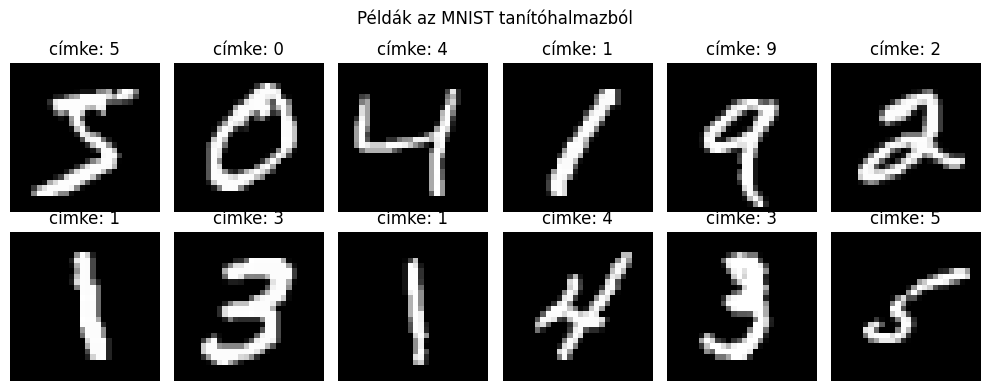

Tanítóminták: 60000, tesztminták: 10000
Egy kép tenzoralakja: torch.Size([1, 28, 28])


In [ ]:
mnist_transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

train_loader = DataLoader(mnist_train, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

# Az első 12 képet a címkéjükkel együtt nézzük meg a modell illesztése előtt.
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for index, axis in enumerate(axes.ravel()):
    image, label = mnist_train[index]
    axis.imshow(image.squeeze(0), cmap="gray")
    axis.set_title(f"címke: {label}")
    axis.axis("off")
plt.suptitle("Példák az MNIST tanítóhalmazból")
plt.tight_layout()
plt.show()

print(f"Tanítóminták: {len(mnist_train)}, tesztminták: {len(mnist_test)}")
print(f"Egy kép tenzoralakja: {mnist_train[0][0].shape}")

A tanítás során **nem teszünk softmax réteget a modell végére**. A `CrossEntropyLoss` stabil módon maga egyesíti a `log_softmax` műveletet és a negatív log-likelihood veszteséget. Ezért közvetlenül a logitokat és az egész számként tárolt címkéket kapja meg.

A modellnek továbbra is pontosan egy rejtett rétege van. A `Flatten` a képeket 784 elemű vektorrá alakítja, a ReLU pedig nemlinearitást visz a modellbe.

1. epoch | veszteség: 0.5167 | tesztpontosság: 92.34%
2. epoch | veszteség: 0.2403 | tesztpontosság: 94.16%
3. epoch | veszteség: 0.1819 | tesztpontosság: 95.16%
4. epoch | veszteség: 0.1460 | tesztpontosság: 95.96%
5. epoch | veszteség: 0.1218 | tesztpontosság: 96.22%


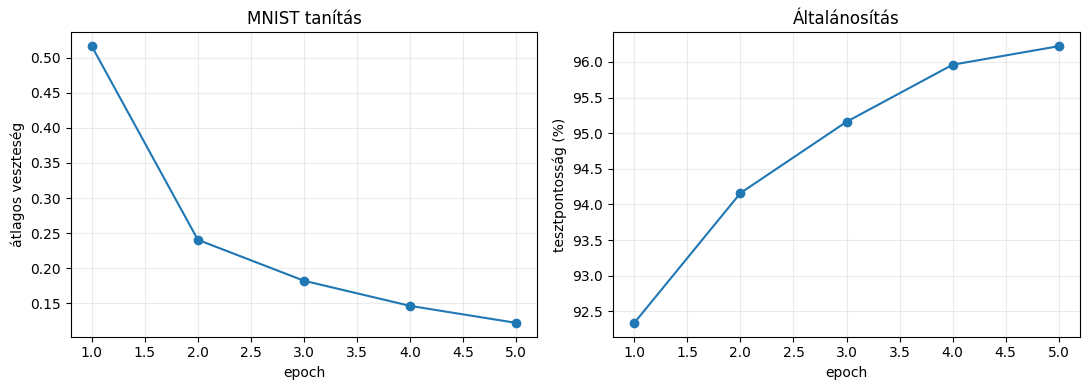

In [13]:
torch.manual_seed(42)
mnist_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)

mnist_criterion = nn.CrossEntropyLoss()
mnist_optimizer = torch.optim.Adam(mnist_model.parameters(), lr=1e-3)
mnist_epoch_losses = []
mnist_test_accuracies = []

for epoch in range(5):
    mnist_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = mnist_model(images)
        loss = mnist_criterion(logits, labels)
        mnist_optimizer.zero_grad()
        loss.backward()
        mnist_optimizer.step()
        running_loss += loss.item() * images.size(0)

    # Értékeléskor nincs szükség gradiensre és a paramétereket sem módosítjuk.
    mnist_model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            predicted_labels = mnist_model(images).argmax(dim=1)
            correct += (predicted_labels == labels).sum().item()

    epoch_loss = running_loss / len(mnist_train)
    test_accuracy = correct / len(mnist_test)
    mnist_epoch_losses.append(epoch_loss)
    mnist_test_accuracies.append(test_accuracy)
    print(f"{epoch + 1}. epoch | veszteség: {epoch_loss:.4f} | tesztpontosság: {100 * test_accuracy:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, 6), mnist_epoch_losses, marker="o")
axes[0].set(xlabel="epoch", ylabel="átlagos veszteség", title="MNIST tanítás")
axes[1].plot(range(1, 6), np.array(mnist_test_accuracies) * 100, marker="o")
axes[1].set(xlabel="epoch", ylabel="tesztpontosság (%)", title="Általánosítás")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

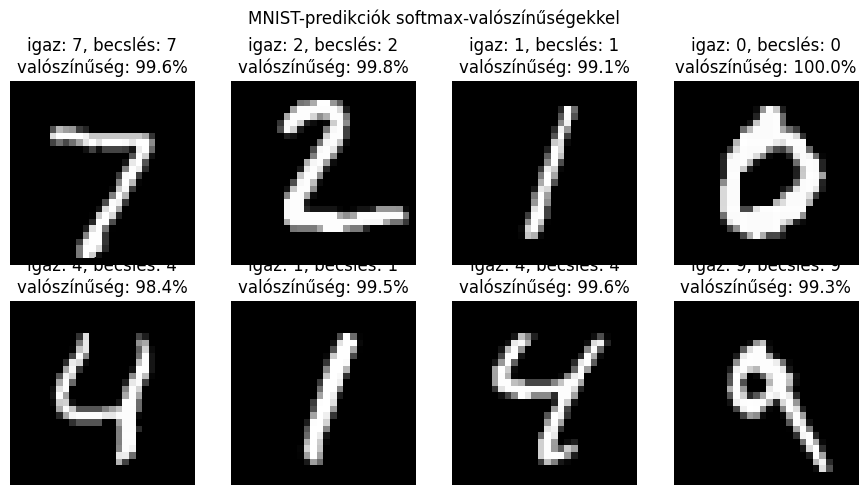

Az első minta valószínűségeinek összege: 0.9999998807907104


In [14]:
mnist_model.eval()
images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    logits = mnist_model(images_device)
    probabilities = torch.softmax(logits, dim=1).cpu()
    predicted_labels = probabilities.argmax(dim=1)

# Az első nyolc tesztképen a legnagyobb softmax-valószínűséget is kiírjuk.
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
for index, axis in enumerate(axes.ravel()):
    predicted_class = predicted_labels[index].item()
    confidence = probabilities[index, predicted_class].item()
    axis.imshow(images[index].squeeze(0), cmap="gray")
    axis.set_title(
        f"igaz: {labels[index].item()}, becslés: {predicted_class}\n"
        f"valószínűség: {confidence:.1%}"
    )
    axis.axis("off")
plt.suptitle("MNIST-predikciók softmax-valószínűségekkel")
plt.tight_layout()
plt.show()

print("Az első minta valószínűségeinek összege:", probabilities[0].sum().item())

---

# Összefoglalás

1. A lineáris regresszióban az MSE minimuma egyszerű esetben analitikusan is meghatározható.
2. A gradiens módszer ugyanezt az optimumot iteratívan keresi, és összetett modellekre is alkalmazható.
3. A vektorizáció sok minta és jellemző egyidejű, hatékony feldolgozását teszi lehetővé.
4. A logisztikus regresszió lineáris döntési határt tanul, ezért nem old meg minden osztályozási feladatot.
5. Egy nemlineáris aktivációt tartalmazó rejtett réteg már görbült döntési határt is képes létrehozni.
6. A nagyobb kapacitás nem mindig jobb: kevés, zajos adaton túlillesztéshez vezethet.
7. Az L2-regularizáció egyszerűbb súlyokat és gyakran jobb általánosítást eredményez.
8. Többosztályos feladatban a softmax valószínűségi eloszlássá alakítja a logitokat.

## Önálló feladatok

- Változtasd meg az egyszerű regresszió tanulási rátáját 0,005-re és 0,5-re. Mit tapasztalsz?
- Adj egy negyedik jellemzőt a többváltozós regresszióhoz, és módosítsd a `Linear` réteget.
- Próbálj 2, 4 és 16 rejtett neuront a gyűrű-adathalmazon. Hogyan változik a döntési határ?
- Vizsgáld meg a `weight_decay` 0, 0,001, 0,01 és 0,1 értékeit.
- Cseréld a ReLU aktivációt Tanh-ra az MNIST-modellben, és hasonlítsd össze a tanulási görbéket.